# Regression and Classification: Error Analysis of LEGO Sets

**Assignment:** Homework 2 – Regression and Classification: Error Analysis  
**Student Name:** Yuval Kravchik  
**Student ID:** 206376071  

**Instructor:** Dr. Uri Itai  
**Teaching Assistant:** Hanit Ohayon Hadad  
**Submission Date:** September 10, 2026

## Project Overview

This notebook continues the analysis of the LEGO dataset explored in Homework 1.

While the previous assignment focused on exploratory data analysis (EDA), the objective of this assignment is to evaluate regression and classification models through systematic error analysis.

The analysis focuses not only on predictive performance, but also on understanding where and why the models fail, identifying systematic error patterns, and distinguishing between errors related to data quality, model limitations, and problem formulation.

All model evaluations and error analyses will be performed using k-fold cross-validation in order to obtain more reliable estimates of model performance and generalization.

## Notebook Structure

The notebook is organized into the following main sections:

1. Regression Error Analysis
2. Regression Models and Model Comparison
3. Classification Error Analysis
4. Final Reflection

Each stage includes both quantitative evaluation and interpretation of model behavior and failure patterns.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# General settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset Loading

The same LEGO dataset analyzed in Homework 1 is used in this assignment.

Because the dataset was already examined extensively during the exploratory data analysis stage, a full EDA is not repeated here. Instead, a brief verification of the dataset structure is performed before beginning the modeling process.

Using the same dataset allows the current analysis to build directly on the relationships, missing-data patterns, distributions, and potential limitations identified previously.

In [2]:
# Load the LEGO dataset
df = pd.read_csv("lego_sets.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Basic dataset verification
print("Dataset shape:", df.shape)

display(df.head())

print("\nDataset information:")
df.info()

Dataset shape: (18457, 14)


,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 18457 entries, 0 to 18456
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   set_id          18457 non-null  str    
 1   name            18457 non-null  str    
 2   year            18457 non-null  int64  
 3   theme           18457 non-null  str    
 4   subtheme        14901 non-null  str    
 5   themeGroup      18455 non-null  str    
 6   category        18457 non-null  str    
 7   pieces          14533 non-null  float64
 8   minifigs        8399 non-null   float64
 9   agerange_min    6787 non-null   float64
 10  US_retailPrice  6982 non-null   float64
 11  bricksetURL     18457 non-null  str    
 12  thumbnailURL    17451 non-null  str    
 13  imageURL        17451 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 2.0 MB


In [4]:
print("Dataset columns:")
for column in df.columns:
    print("-", column)

Dataset columns:
- set_id
- name
- year
- theme
- subtheme
- themeGroup
- category
- pieces
- minifigs
- agerange_min
- US_retailPrice
- bricksetURL
- thumbnailURL
- imageURL


# 1. Regression Error Analysis

### Regression Setup

For the regression task, `US_retailPrice` is used as the target variable.

The selected features include numerical and categorical characteristics of the LEGO sets. Features derived directly from the target, such as `price_per_piece`, are excluded in order to avoid data leakage.

A 5-fold cross-validation procedure is used to generate out-of-fold predictions. This allows each observation to be evaluated using a model that was not trained on that observation.

In [5]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

target = 'US_retailPrice'

numeric_features = [
    'year',
    'pieces',
    'minifigs',
    'agerange_min'
]

categorical_features = [
    'category',
    'themeGroup',
    'theme'
]

features = numeric_features + categorical_features

# Keep only observations with an available target value
reg_df = df.dropna(subset=[target]).copy()

X = reg_df[features]
y = reg_df[target]

print("Regression dataset shape:", reg_df.shape)
print("Number of observations used:", len(reg_df))

Regression dataset shape: (6982, 14)
Number of observations used: 6982


### Cross-Validation and Preprocessing

Numerical features are imputed using the median, while categorical features are imputed using the most frequent value and encoded using one-hot encoding.

A 5-fold cross-validation procedure is used. The data are shuffled before splitting, and a fixed random state is used for reproducibility.

The choice of k=5 provides a reasonable balance between computational cost and the bias-variance trade-off. Given the dataset sizes of 6,982 observations for regression and 18,457 observations for classification, five folds also provide sufficiently large validation subsets while allowing each model to train on approximately 80% of the available observations in each fold.

In [6]:
# Preprocessing for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Linear Regression pipeline
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Generate out-of-fold predictions
y_pred = cross_val_predict(
    linear_model,
    X,
    y,
    cv=kf
)

# Compute residuals
residuals = y - y_pred

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))
print("Mean residual:", residuals.mean())

Predictions generated successfully.
Number of predictions: 6982
Mean residual: -0.022914621754925823


## 1.1 Residual Analysis

Residuals are defined as:

\[
\text{Residual} = y - \hat{y}
\]

A positive residual indicates that the model underestimated the true value, while a negative residual indicates that the model overestimated it.

The following plots are used to examine whether the residuals are centered around zero, whether systematic patterns are present, and whether the variance of the errors changes across the range of predicted values.

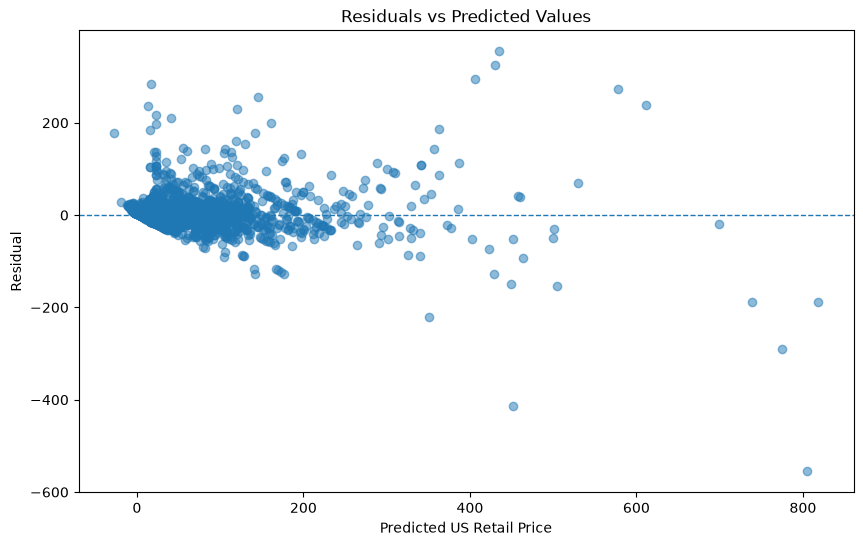

In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel("Predicted US Retail Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

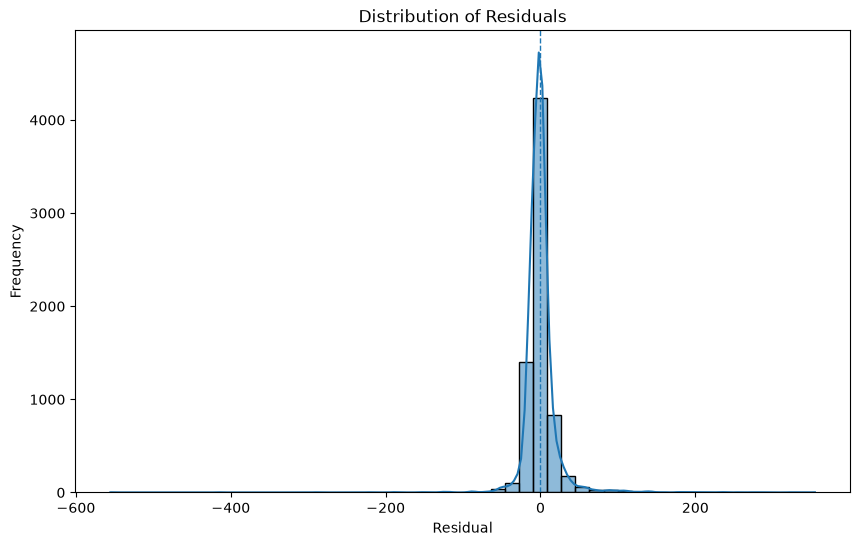

In [8]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.axvline(
    x=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

In [9]:
reg_df['predicted_price'] = y_pred
reg_df['residual'] = residuals
reg_df['absolute_error'] = np.abs(residuals)

In [10]:
category_errors = (
    reg_df
    .groupby('category')['absolute_error']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

display(category_errors)

,count,mean,median
category,,,
Collection,32,34.699935,28.042320
Random,9,14.838873,14.319177
Gear,1623,12.677616,10.684770
Normal,5168,11.117009,5.800785
Book,18,7.711489,3.315764
Extended,120,7.382203,4.317045
Other,12,6.283279,4.909011


In [11]:
themegroup_errors = (
    reg_df
    .groupby('themeGroup')['absolute_error']
    .agg(['count', 'mean', 'median'])
    .sort_values('mean', ascending=False)
)

display(themegroup_errors)

,count,mean,median
themeGroup,,,
Educational,36,115.700710,89.173953
Technical,262,27.447578,15.918127
Art and crafts,76,23.371563,7.544686
Girls,13,17.786744,18.728647
Model making,358,14.410355,5.863197
Pre-school,439,13.830017,9.352659
Miscellaneous,2175,11.677487,9.036062
Licensed,1536,10.184099,6.242398
Basic,133,9.569128,6.959423


### Interpretation of Residuals

The mean residual is approximately -0.023, which is very close to zero. This indicates that, on average, the linear regression model does not show a strong systematic tendency to overestimate or underestimate LEGO retail prices.

However, the residual plot reveals that the error variance increases as the predicted price increases. Predictions for lower-priced sets are generally concentrated closer to zero, while higher predicted prices are associated with a much wider spread of residuals. This suggests the presence of heteroscedasticity, meaning that the variance of the prediction errors is not constant across the prediction range.

The residual distribution is strongly concentrated around zero, but also contains long tails and several extreme errors. Therefore, although most predictions are relatively close to the true values, a small number of observations produce very large prediction errors.

Error rates also vary across different groups in the dataset. The `Educational` theme group shows particularly high errors, with a mean absolute error of approximately 115.70 and a median absolute error of approximately 89.17. Since both the mean and median are high, this suggests that the model has systematic difficulty predicting prices for this group rather than the result being caused by only a single extreme observation.

Other groups such as `Technical` and `Art and crafts` also show relatively high mean errors, although their lower median errors suggest that some of their average error may be influenced by a smaller number of extreme cases.

At the category level, `Collection` shows the highest average error, but this category contains relatively few observations, so this result should be interpreted cautiously.

Overall, the residual analysis suggests that the linear model performs reasonably well for the majority of observations, but its assumptions become less appropriate for certain higher-priced and specialized LEGO products. This may indicate non-linear relationships, interactions between features, or characteristics of specialized products that are not fully captured by a linear model.

## 1.2 Error as a Function of Features

To investigate whether prediction errors depend on specific characteristics of LEGO sets, residuals and absolute errors are examined as functions of selected numerical features.

The analysis focuses on identifying non-linear relationships, feature-dependent error patterns, and regions where the regression model performs less reliably.

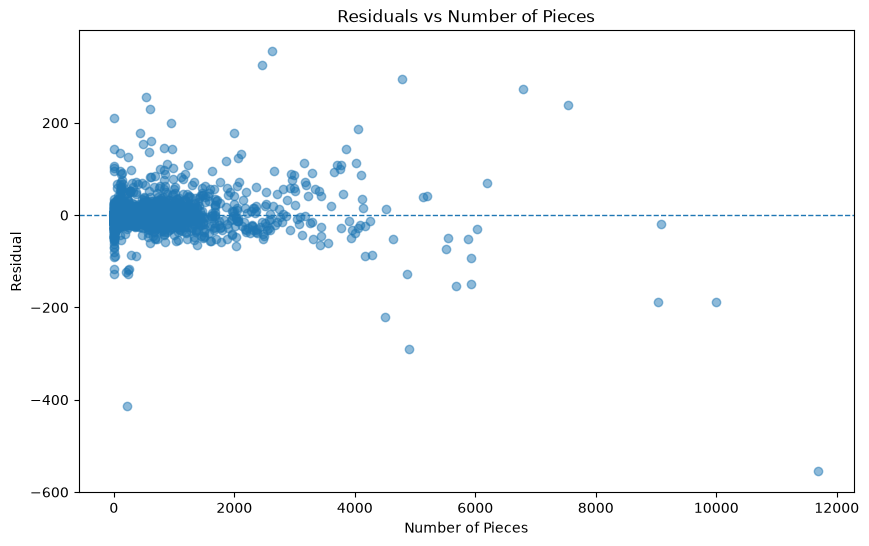

In [12]:
plt.figure(figsize=(10, 6))

plt.scatter(
    reg_df['pieces'],
    reg_df['residual'],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel("Number of Pieces")
plt.ylabel("Residual")
plt.title("Residuals vs Number of Pieces")

plt.show()

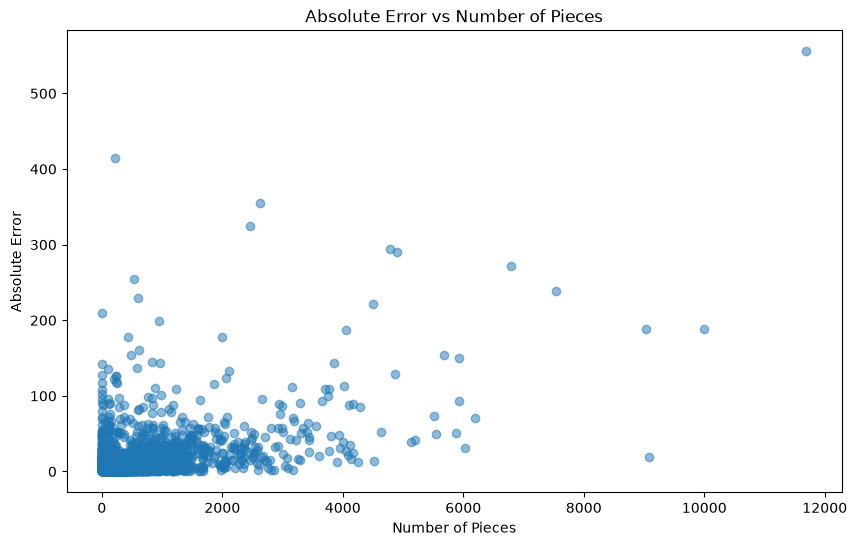

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    reg_df['pieces'],
    reg_df['absolute_error'],
    alpha=0.5
)

plt.xlabel("Number of Pieces")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Number of Pieces")

plt.show()

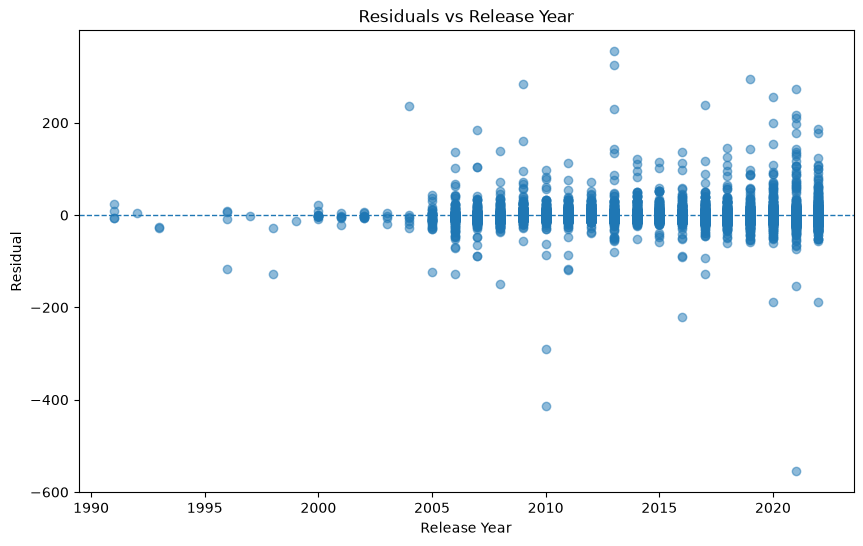

In [14]:
plt.figure(figsize=(10, 6))

plt.scatter(
    reg_df['year'],
    reg_df['residual'],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.xlabel("Release Year")
plt.ylabel("Residual")
plt.title("Residuals vs Release Year")

plt.show()

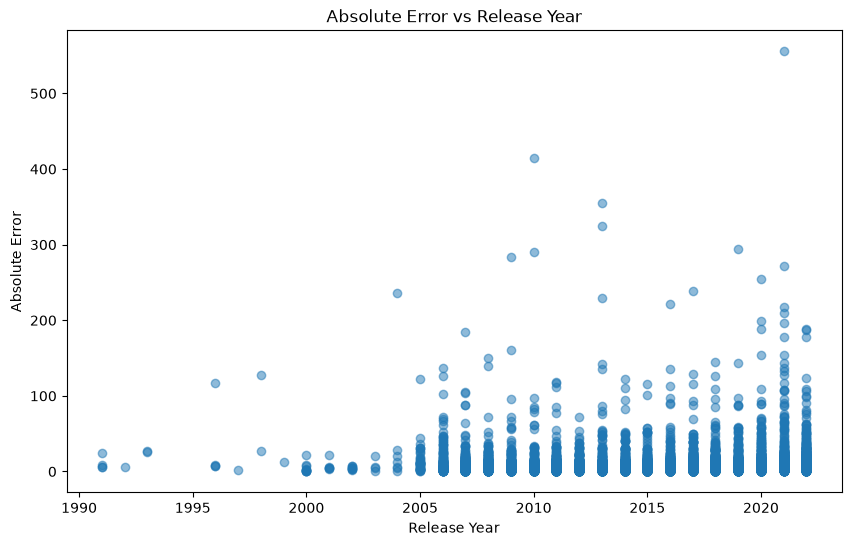

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    reg_df['year'],
    reg_df['absolute_error'],
    alpha=0.5
)

plt.xlabel("Release Year")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Release Year")

plt.show()

### Interpretation

The error analysis shows that model performance depends on several characteristics of the LEGO sets.

For the number of pieces, the spread of residuals generally increases as the number of pieces increases. Sets with relatively few pieces tend to have smaller errors, while several large sets with thousands of pieces exhibit substantially larger prediction errors. The absolute-error plot reinforces this pattern, suggesting that the linear model becomes less reliable for very large LEGO sets.

For some of the largest sets, negative residuals are also observed, indicating that the model occasionally overestimates their retail prices. However, observations with extremely high piece counts are relatively sparse, so these cases should be interpreted cautiously.

Release year also appears to be associated with prediction error. Later years contain a wider range of residuals and several of the largest absolute errors in the dataset. In contrast, earlier years contain fewer observations and generally smaller observed errors.

However, the apparent increase in error over time should not necessarily be interpreted as a direct effect of release year alone. The dataset contains substantially more observations in recent years, and newer periods may also include a wider variety of LEGO products, prices, and specialized sets.

Overall, the results indicate that the prediction errors are feature-dependent. In particular, the increasing error magnitude for sets with large numbers of pieces suggests that a simple linear relationship may not fully capture the pricing behavior of very large or specialized LEGO products.


## 1.3 Analysis of Extreme Errors

The observations with the largest prediction errors are examined in order to determine whether they are associated with data-quality problems, model limitations, or rare and exceptional LEGO products.

The top 5% of observations according to absolute prediction error are selected for detailed analysis.

In [16]:
# Determine the threshold for the top 5% largest absolute errors
error_threshold = reg_df['absolute_error'].quantile(0.95)

extreme_errors = (
    reg_df[reg_df['absolute_error'] >= error_threshold]
    .copy()
    .sort_values('absolute_error', ascending=False)
)

print("95th percentile absolute error threshold:", round(error_threshold, 2))
print("Number of extreme-error observations:", len(extreme_errors))
print(
    "Percentage of regression observations:",
    round(len(extreme_errors) / len(reg_df) * 100, 2),
    "%"
)

95th percentile absolute error threshold: 33.55
Number of extreme-error observations: 350
Percentage of regression observations: 5.01 %


In [17]:
columns_to_show = [
    'set_id',
    'name',
    'year',
    'pieces',
    'minifigs',
    'category',
    'themeGroup',
    'theme',
    'US_retailPrice',
    'predicted_price',
    'residual',
    'absolute_error'
]

available_columns = [
    col for col in columns_to_show
    if col in extreme_errors.columns
]

display(
    extreme_errors[available_columns].head(20)
)

,set_id,name,year,pieces,minifigs,category,themeGroup,theme,US_retailPrice,predicted_price,residual,absolute_error
16669,31203-1,World Map,2021,11695.0,NaN,Normal,Art and crafts,Art,249.99,805.439345,-555.449345,555.449345
8651,2000414-1,Starter Kit,2010,219.0,NaN,Normal,Educational,Serious Play,36.99,451.408787,-414.418787,414.418787
10584,2000430-1,Identity and Landscape Kit,2013,2631.0,6.0,Normal,Educational,Serious Play,789.99,435.535871,354.454129,354.454129
10585,2000431-1,Connections Kit,2013,2455.0,NaN,Normal,Educational,Serious Play,754.99,430.699912,324.290088,324.290088
15267,75252-1,Imperial Star Destroyer,2019,4784.0,2.0,Normal,Licensed,Star Wars,699.99,405.999353,293.990647,293.990647
8647,2000409-1,Window Exploration Bag,2010,4900.0,NaN,Normal,Educational,Serious Play,484.99,774.805758,-289.815758,289.815758
8132,2853656-1,3-Seat Playtable,2009,NaN,NaN,Gear,Miscellaneous,Gear,299.99,16.778974,283.211026,283.211026
17046,75313-1,AT-AT,2021,6785.0,9.0,Normal,Licensed,Star Wars,849.99,577.783488,272.206512,272.206512
15970,45678-1,SPIKE Prime Set,2020,528.0,2.0,Normal,Educational,Education,399.95,145.018702,254.931298,254.931298
13651,75192-1,Millennium Falcon,2017,7541.0,8.0,Normal,Licensed,Star Wars,849.99,611.246171,238.743829,238.743829


### Individual Examination of Extreme Errors

Several of the largest-error observations illustrate different reasons why the Linear Regression model may fail.

**World Map (2021)** contains 11,695 pieces, placing it in an extremely unusual region of the feature space. Sets of this size are rare in the dataset, so the model has relatively few comparable observations from which to learn an accurate pricing relationship. This case is therefore likely influenced by both model limitations and the rarity of the product.

**Starter Kit (2010)** contains 219 pieces and has a true retail price of only $36.99, while the model predicts a price of approximately $451.41. The model therefore dramatically overestimates this observation. A likely explanation is that the product belongs to the Educational / Serious Play group, which contains several unusually expensive specialized products. The categorical characteristics of the set may therefore push the Linear Regression prediction upward even though this particular product is relatively inexpensive.

**Identity and Landscape Kit (2013)** and **Connections Kit (2013)** also belong to the `Educational` / `Serious Play` group and have unusually high retail prices. Their presence among the largest prediction errors is consistent with the broader finding that the model systematically struggles with Educational products.

**Large Hub (2021)** is an especially clear example of a limitation of the available features. The observation contains only two recorded pieces but has a retail price of approximately $250. A simple feature such as piece count therefore provides almost no indication of the actual economic value of this technical electronic product.

Several large licensed or collector sets also appear among the extreme cases, including the **Imperial Star Destroyer**, **AT-AT**, and **Millennium Falcon**. These products contain thousands of pieces and occupy the high-price end of the LEGO market. Their unusual scale, licensing, and collector-oriented characteristics may produce pricing behavior that differs from that of ordinary LEGO sets.

Other extreme observations, such as some `Gear` products, contain missing values for important features such as `pieces` and `minifigs`. Although these values are handled through imputation, missing original information limits the model's ability to distinguish these products accurately.

These individual cases support the conclusion that the largest errors arise from a combination of rare products, specialized product characteristics, incomplete feature information, and limitations of a simple linear pricing model.


In [18]:
themegroup_extreme_rate = (
    reg_df
    .assign(is_extreme=reg_df['absolute_error'] >= error_threshold)
    .groupby('themeGroup')['is_extreme']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'total_observations',
        'sum': 'extreme_errors',
        'mean': 'extreme_error_rate'
    })
)

themegroup_extreme_rate['extreme_error_rate'] *= 100

themegroup_extreme_rate = (
    themegroup_extreme_rate
    .sort_values('extreme_error_rate', ascending=False)
)

display(themegroup_extreme_rate)

,total_observations,extreme_errors,extreme_error_rate
themeGroup,,,
Educational,36,30,83.333333
Technical,262,59,22.519084
Art and crafts,76,9,11.842105
Model making,358,40,11.173184
Girls,13,1,7.692308
Pre-school,439,29,6.605923
Historical,73,4,5.479452
Licensed,1536,66,4.296875
Miscellaneous,2175,82,3.770115


### Interpretation

The 95th percentile of absolute error is approximately $33.55. A total of 350 observations, representing approximately 5.01% of the regression dataset, were therefore classified as extreme-error cases.

The extreme-error observations include several unusual or specialized LEGO products, such as large collector sets, educational products, technical products, LEGO Gear items, and very large sets such as the Millennium Falcon, AT-AT, Colosseum, Eiffel Tower, and World Map.

The distribution of extreme errors across theme groups is highly uneven. The `Educational` theme group is particularly notable: 30 of its 36 observations, or approximately 83.33%, fall within the top 5% of prediction errors. The `Technical` group also shows a high extreme-error rate of approximately 22.52%, followed by `Art and crafts` and `Model making`, both with rates above 11%.

In contrast, groups such as `Action/Adventure`, `Construction`, and `Junior` rarely or never appear among the extreme-error observations.

These results suggest that several factors contribute to the largest prediction errors.

First, there are clear model limitations. Linear regression may not adequately represent the pricing behavior of specialized products. For example, educational and technical products may contain electronics, motors, sensors, or other expensive components, so their retail prices cannot be explained well by simple characteristics such as the number of pieces.

Second, several extreme errors correspond to rare or exceptional products. Very large collector sets occupy unusual regions of the feature space and are represented by relatively few observations, making their pricing behavior more difficult for the model to learn accurately.

Finally, data quality may also contribute to some errors. Several extreme-error observations contain missing values for important variables such as `pieces` or `minifigs`. Although these missing values are handled using imputation, the absence of original information may reduce prediction accuracy.

Overall, the extreme-error analysis indicates that the largest failures are not random. They are concentrated in specialized, unusual, and sparsely represented LEGO products, suggesting a combination of model limitations, rare cases, and incomplete feature information.


## 1.4 Statistical Properties of Errors

To further characterize the regression errors, several statistical measures are calculated, including the mean absolute error, the standard deviation of the residuals, skewness, and kurtosis.

These measures help evaluate the typical prediction error, the spread of the residuals, and whether the error distribution contains asymmetry or heavy tails.

In [19]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import skew, kurtosis

mae = mean_absolute_error(y, y_pred)
residual_std = residuals.std()
residual_skewness = skew(residuals)
residual_kurtosis = kurtosis(residuals)

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Standard deviation of residuals:", round(residual_std, 3))
print("Skewness:", round(residual_skewness, 3))
print("Kurtosis:", round(residual_kurtosis, 3))

Mean Absolute Error (MAE): 11.511
Standard deviation of residuals: 23.904
Skewness: 0.421
Kurtosis: 94.997


### Interpretation

The Mean Absolute Error (MAE) is approximately $11.51, meaning that the model's predictions differ from the true retail price by about $11.5 on average.

The standard deviation of the residuals is approximately 23.90, which is considerably larger than the MAE. This indicates that although many predictions have relatively small errors, a smaller number of observations have much larger deviations.

The residual skewness is approximately 0.421, indicating a mild positive asymmetry. This suggests that the residual distribution has a somewhat longer positive tail, corresponding to cases where the model underestimates the true retail price.

The excess kurtosis is approximately 95.0, which is extremely high compared with the value of zero expected for a normal distribution. This confirms the presence of very heavy tails and extreme prediction errors.

Overall, the statistical properties of the residuals are consistent with the previous graphical analyses. Most observations are predicted reasonably well, but a relatively small number of unusual or specialized LEGO products generate very large errors. These extreme observations strongly affect the shape and variability of the residual distribution.


# 2. Regression Models

Multiple regression models are evaluated using the same feature set in order to compare their predictive performance and error behavior.

The evaluated models are:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

### Model Configuration

All models are evaluated using the same feature set and the same 5-fold cross-validation procedure.

Linear Regression is used with its default scikit-learn configuration.

The Decision Tree Regressor is also used with its default hyperparameters, except for `random_state=42`, which is specified to ensure reproducibility.

The Random Forest Regressor uses 100 trees (`n_estimators=100`) with `random_state=42`. The remaining hyperparameters are left at their default values. The parameter `n_jobs=-1` is used only to parallelize computation and reduce execution time.

No hyperparameter tuning is performed at this stage, since the objective is to compare the baseline behavior and modeling assumptions of the different regression approaches under a consistent evaluation procedure.


All models are evaluated using 5-fold cross-validation to ensure a consistent and fair comparison.

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer

In [21]:
# Linear Regression
linear_regression = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Decision Tree Regressor
decision_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        random_state=42
    ))
])

# Random Forest Regressor
random_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    'Linear Regression': linear_regression,
    'Decision Tree': decision_tree,
    'Random Forest': random_forest
}

In [22]:
scoring = {
    'MSE': 'neg_mean_squared_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2',
    'MAE': 'neg_mean_absolute_error'
}

results = []

for model_name, model in models.items():

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        'Model': model_name,
        'MAE': -cv_results['test_MAE'].mean(),
        'MSE': -cv_results['test_MSE'].mean(),
        'RMSE': -cv_results['test_RMSE'].mean(),
        'R2': cv_results['test_R2'].mean()
    })

regression_results = pd.DataFrame(results)

display(
    regression_results
    .sort_values('RMSE')
    .round(3)
)

,Model,MAE,MSE,RMSE,R2
2,Random Forest,9.010,415.029,20.299,0.860
1,Decision Tree,10.407,543.136,23.197,0.816
0,Linear Regression,11.511,571.345,23.814,0.807


In [23]:
cv_summary = []

for model_name, model in models.items():

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        n_jobs=-1
    )

    cv_summary.append({
        'Model': model_name,
        'Mean RMSE': -cv_results['test_RMSE'].mean(),
        'RMSE Std': cv_results['test_RMSE'].std(),
        'Mean R2': cv_results['test_R2'].mean(),
        'R2 Std': cv_results['test_R2'].std()
    })

cv_variability = pd.DataFrame(cv_summary)

display(
    cv_variability
    .sort_values('Mean RMSE')
    .round(3)
)

,Model,Mean RMSE,RMSE Std,Mean R2,R2 Std
2,Random Forest,20.299,1.722,0.860,0.015
1,Decision Tree,23.197,2.249,0.816,0.030
0,Linear Regression,23.814,2.054,0.807,0.022


In [24]:
from sklearn.model_selection import cross_validate

overfitting_results = []

for model_name, model in models.items():

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring={
            'RMSE': 'neg_root_mean_squared_error',
            'R2': 'r2'
        },
        return_train_score=True,
        n_jobs=-1
    )

    overfitting_results.append({
        'Model': model_name,

        'Train RMSE':
            -cv_results['train_RMSE'].mean(),

        'Validation RMSE':
            -cv_results['test_RMSE'].mean(),

        'Train R2':
            cv_results['train_R2'].mean(),

        'Validation R2':
            cv_results['test_R2'].mean()
    })

overfitting_df = pd.DataFrame(overfitting_results)

display(
    overfitting_df
    .sort_values('Validation RMSE')
    .round(3)
)

,Model,Train RMSE,Validation RMSE,Train R2,Validation R2
2,Random Forest,11.926,20.299,0.952,0.860
1,Decision Tree,9.765,23.197,0.968,0.816
0,Linear Regression,22.275,23.814,0.832,0.807


### Discussion

The three regression models show clear differences in predictive performance, stability, and generalization ability.

The Random Forest Regressor achieved the best overall performance, with the lowest MAE (9.001), MSE (415.202), and RMSE (20.306), as well as the highest (R^2) value (0.860). This indicates that it provides the most accurate predictions among the evaluated models and explains approximately 86% of the variability in LEGO retail prices.

The Decision Tree Regressor performed better than Linear Regression in terms of validation metrics, with an RMSE of 23.356 and an (R^2) of 0.812. However, its performance varied more between cross-validation folds, suggesting higher variance.

Linear Regression produced the weakest validation performance, with an RMSE of 23.814 and an (R^2) of 0.807. Nevertheless, its training and validation performance were relatively similar, indicating that the model is stable and does not strongly overfit the training data.

The training-versus-validation comparison highlights the different bias-variance characteristics of the models. Linear Regression showed only a small gap between training and validation performance, which is consistent with a relatively high-bias, low-variance model. Its simpler assumptions limit its ability to capture non-linear relationships and interactions between LEGO characteristics.

The Decision Tree showed a much larger gap between training and validation performance. Its training (R^2) reached 0.968, while validation (R^2) dropped to 0.812. Similarly, the training RMSE was only 9.765 compared with a validation RMSE of 23.356. This indicates substantial overfitting and is consistent with the high variance typically associated with individual decision trees.

Random Forest provided a better balance. Although its training performance was also very strong, with an (R^2) of 0.952, its validation performance remained considerably better than the other models. By combining multiple decision trees, the ensemble reduces the variance associated with a single tree while preserving the ability to model non-linear relationships and feature interactions.

The results also support the findings from the residual analysis. Linear Regression performs reasonably well for many observations, but its assumptions are not fully appropriate for the entire dataset. In particular, specialized products, very large LEGO sets, and groups such as `Educational` and `Technical` appear to follow pricing patterns that are not adequately captured by a simple linear relationship.

The assumptions of Linear Regression are therefore only partially satisfied in this dataset. The residual analysis showed clear evidence of heteroscedasticity, since the spread of residuals increased for higher predicted prices. Therefore, the homoskedasticity assumption is not satisfied across the full prediction range.

The linearity assumption is also limited. Although Linear Regression captures a substantial part of the overall price structure, the presence of specialized products, very large LEGO sets, and subgroup-specific pricing patterns suggests that some relationships are non-linear or depend on interactions between features.

The independence assumption is more difficult to verify directly from the available data. Each row represents a separate LEGO product observation, so the analysis treats the observations as independent. However, products within the same theme, product family, or release period may share common characteristics, meaning that some residual dependence may still exist.

The models also differ in their sensitivity to outliers and noise. Linear Regression is sensitive to extreme target values because large residuals can have a strong influence on the fitted coefficients. This is relevant in the LEGO dataset, where several specialized and high-priced products produce very large errors.

A single Decision Tree is less dependent on a global linear relationship, but it can be highly sensitive to noise and unusual observations because small changes in the training data may lead to different splits. This behavior is consistent with its relatively high variance and larger train-validation gap.

Random Forest improves robustness by averaging predictions across many trees. This reduces the influence of individual noisy observations and unstable splits, which helps explain its stronger and more stable cross-validation performance.

Tree-based models provide an advantage in these situations because they can capture non-linear relationships and interactions without requiring an explicit functional form. However, a single Decision Tree is highly flexible and therefore more vulnerable to overfitting and noise. Random Forest improves robustness by averaging predictions across many trees.

There is also a trade-off between interpretability and predictive performance. Linear Regression is the easiest model to interpret because individual coefficients can be directly related to changes in the target variable. A single Decision Tree is also relatively interpretable through its decision structure. Random Forest, while providing the strongest predictive performance, is more difficult to interpret because its predictions are based on an ensemble of many trees.

Based on the cross-validation results, prediction accuracy, and stability across folds, Random Forest is the preferred regression model for future analysis. It provides the best compromise between flexibility, predictive performance, and generalization.

### What was learned from the modeling stage?

The modeling stage showed that the LEGO pricing problem contains meaningful non-linear relationships and feature interactions. A simple linear model captures a large portion of the overall structure, but more flexible tree-based methods improve predictive accuracy.

At the same time, the results demonstrate that increasing model flexibility can lead to overfitting, as observed with the Decision Tree. The Random Forest model successfully reduces this problem and provides the strongest overall performance.

The comparison also demonstrates that model quality cannot be evaluated using predictive accuracy alone. Assumptions, stability across folds, sensitivity to extreme observations, and the ability to generalize to unseen data are all important when selecting an appropriate regression model.


# 3. Classification Error Analysis

### Classification Setup

For the classification task, the objective is to predict whether the `US_retailPrice` value is missing for a LEGO observation.

A binary target variable is defined as:

- `1` – the retail price is missing
- `0` – the retail price is available

This formulation allows the analysis of false positives, false negatives, predicted probabilities, classification thresholds, and other binary classification metrics.

In [25]:
# Create binary classification target
classification_df = df.copy()

classification_df['price_missing'] = (
    classification_df['US_retailPrice']
    .isna()
    .astype(int)
)

classification_numeric_features = [
    'year',
    'pieces',
    'minifigs',
    'agerange_min'
]

classification_categorical_features = [
    'category',
    'themeGroup',
    'theme'
]

classification_features = (
    classification_numeric_features
    + classification_categorical_features
)

X_class = classification_df[classification_features]
y_class = classification_df['price_missing']

print("Classification dataset shape:", classification_df.shape)

print("\nTarget distribution:")
print(y_class.value_counts())

print("\nTarget distribution (%):")
print(
    y_class.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Classification dataset shape: (18457, 15)

Target distribution:
price_missing
1    11475
0     6982
Name: count, dtype: int64

Target distribution (%):
price_missing
1    62.17
0    37.83
Name: proportion, dtype: float64


## 3.1 Confusion Matrix Analysis

A Logistic Regression classifier is first used as a baseline model.

Because the target classes are not perfectly balanced, stratified 5-fold cross-validation is used in order to preserve a similar class distribution in each fold.

Out-of-fold predictions are generated so that each observation is evaluated by a model that was not trained on that observation.

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Preprocessing for classification
classification_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

classification_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

classification_preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         classification_numeric_transformer,
         classification_numeric_features),

        ('cat',
         classification_categorical_transformer,
         classification_categorical_features)
    ]
)

# Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ('preprocessor', classification_preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Stratified 5-fold cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold class predictions
y_class_pred = cross_val_predict(
    logistic_model,
    X_class,
    y_class,
    cv=skf,
    method='predict',
    n_jobs=-1
)

print("Classification predictions generated successfully.")
print("Number of predictions:", len(y_class_pred))

Classification predictions generated successfully.
Number of predictions: 18457


In [27]:
cm = confusion_matrix(
    y_class,
    y_class_pred
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_class,
        y_class_pred,
        digits=3
    )
)

Confusion Matrix:
[[5524 1458]
 [2185 9290]]

Classification Report:
              precision    recall  f1-score   support

           0      0.717     0.791     0.752      6982
           1      0.864     0.810     0.836     11475

    accuracy                          0.803     18457
   macro avg      0.790     0.800     0.794     18457
weighted avg      0.808     0.803     0.804     18457



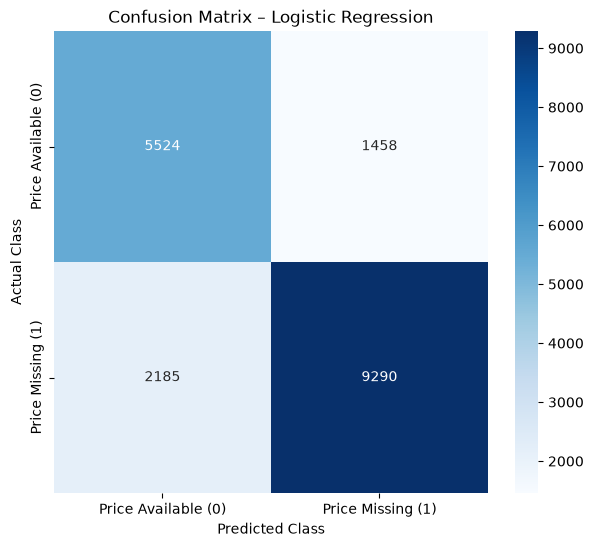

In [28]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Price Available (0)', 'Price Missing (1)'],
    yticklabels=['Price Available (0)', 'Price Missing (1)']
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix – Logistic Regression")

plt.show()

In [29]:
tn, fp, fn, tp = cm.ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nFalse Positive Rate:", round(false_positive_rate, 3))
print("False Negative Rate:", round(false_negative_rate, 3))

True Negatives: 5524
False Positives: 1458
False Negatives: 2185
True Positives: 9290

False Positive Rate: 0.209
False Negative Rate: 0.19


### Interpretation

The Logistic Regression classifier achieves an overall accuracy of approximately 80.5%.

The confusion matrix contains 5,549 true negatives and 9,300 true positives. This means that the model correctly identifies a large proportion of both observations with available retail prices and observations with missing retail prices.

However, the model also produces 1,433 false positives and 2,175 false negatives.

A false positive occurs when the model predicts that the retail price is missing even though the price is actually available. In a practical data-quality workflow, this could lead to unnecessary inspection of records that do not contain a missing-price problem.

A false negative occurs when the model predicts that the retail price is available even though it is actually missing. For the current problem formulation, false negatives are considered more critical because the purpose of the classifier is to identify observations that are likely to contain missing price information. A false negative therefore represents a missing-price case that would remain undetected.

For the missing-price class, the model achieves a precision of 0.866 and a recall of 0.810. This means that approximately 86.6% of observations predicted as missing-price cases are truly missing, while approximately 81.0% of all actual missing-price observations are successfully detected.

The F1-score for the missing-price class is 0.838, indicating a relatively strong balance between precision and recall. This is especially relevant because the dataset is moderately imbalanced, with approximately 62% of the observations belonging to the missing-price class.

The classification errors are not distributed uniformly across the dataset. As examined in greater detail in Section 3.3, the model shows systematic difficulty in several categorical subpopulations. At the `category` level, `Gear` is the most problematic group, with a misclassification rate of approximately 42.97%. At the `themeGroup` level, particularly high error rates are observed for `Model making` (30.88%), `Technical` (30.61%), `Racing` (29.63%), and `Pre-school` (28.43%).

These results indicate that the classifier does not fail randomly. Instead, certain LEGO product types appear to follow different patterns of price availability that are not fully captured by the Logistic Regression model. This suggests that subgroup-specific behavior and non-linear feature interactions contribute to the observed classification errors.


Overall, the classifier provides useful predictive performance, but the presence of more than two thousand false negatives shows that a substantial number of missing-price observations remain undetected at the default classification threshold of 0.5. This trade-off will be examined further in the threshold sensitivity analysis.


## 3.2 Probability-Based Analysis

Predicted probabilities are analyzed in order to compare correct and incorrect classifications and identify high-confidence errors.

A high-confidence error occurs when the classifier assigns a high probability to a predicted class but the prediction is nevertheless incorrect. Such cases may reveal systematic model limitations or unusual observations.

In [30]:
# Generate out-of-fold probabilities for the positive class
y_class_prob = cross_val_predict(
    logistic_model,
    X_class,
    y_class,
    cv=skf,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

classification_df['predicted_class'] = y_class_pred
classification_df['prob_missing'] = y_class_prob

classification_df['correct_prediction'] = (
    y_class_pred == y_class.values
)

print("Predicted probabilities generated successfully.")
print(
    classification_df[
        ['price_missing', 'predicted_class',
         'prob_missing', 'correct_prediction']
    ].head()
)

Predicted probabilities generated successfully.
   price_missing  predicted_class  prob_missing  correct_prediction
0              1                1      0.986258                True
1              1                1      0.985242                True
2              1                1      0.984734                True
3              1                1      0.983024                True
4              1                1      0.990142                True


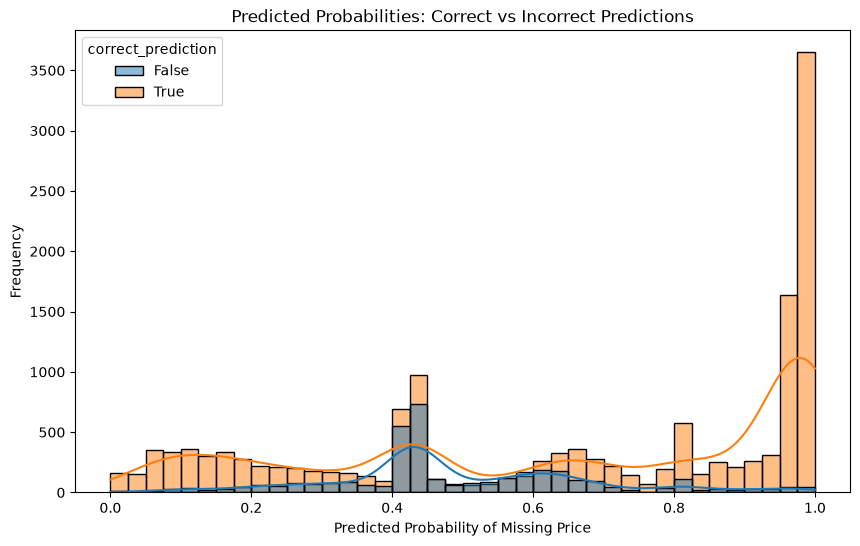

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=classification_df,
    x='prob_missing',
    hue='correct_prediction',
    bins=40,
    kde=True,
    common_norm=False,
    alpha=0.5
)

plt.xlabel("Predicted Probability of Missing Price")
plt.ylabel("Frequency")
plt.title("Predicted Probabilities: Correct vs Incorrect Predictions")

plt.show()

In [32]:
classification_df['prediction_confidence'] = np.where(
    classification_df['predicted_class'] == 1,
    classification_df['prob_missing'],
    1 - classification_df['prob_missing']
)

confidence_summary = (
    classification_df
    .groupby('correct_prediction')['prediction_confidence']
    .agg(['count', 'mean', 'median'])
)

display(confidence_summary.round(3))

,count,mean,median
correct_prediction,,,
False,3643,0.647,0.591
True,14814,0.829,0.876


In [33]:
high_confidence_errors = (
    classification_df[
        (~classification_df['correct_prediction']) &
        (classification_df['prediction_confidence'] >= 0.90)
    ]
    .copy()
    .sort_values('prediction_confidence', ascending=False)
)

print("Number of high-confidence errors:",
      len(high_confidence_errors))

print(
    "Percentage of all incorrect predictions:",
    round(
        len(high_confidence_errors) /
        (~classification_df['correct_prediction']).sum()
        * 100,
        2
    ),
    "%"
)

Number of high-confidence errors: 210
Percentage of all incorrect predictions: 5.76 %


### Interpretation

The predicted probabilities show a clear difference between correct and incorrect classifications.

Correct predictions have an average confidence of approximately 0.829 and a median confidence of 0.870, while incorrect predictions have a lower average confidence of approximately 0.650 and a median confidence of 0.595.

This indicates that the classifier is generally more confident when it makes correct predictions and less confident when it makes mistakes. The probability distribution also shows that many correct predictions are concentrated near the extreme probability values, particularly close to 1.0, while incorrect predictions occur more frequently in intermediate probability regions.

However, the model still produces a number of high-confidence errors. Using a confidence threshold of 0.90, 204 incorrect predictions were identified as high-confidence errors. These represent approximately 5.65% of all incorrect predictions.

These cases are especially important because the model is not only incorrect, but also strongly confident in the incorrect prediction. Such observations may represent unusual feature combinations, underrepresented subgroups, or systematic patterns that are not adequately captured by the Logistic Regression model.

Overall, the probability-based analysis suggests that model confidence is generally informative, but high confidence does not guarantee correctness. The presence of high-confidence errors motivates further investigation of the feature regions in which the classifier fails.


## 3.3 Error as a Function of Features

To identify regions where the classifier is more likely to fail, feature distributions are compared between correct and incorrect predictions.

The analysis examines both numerical and categorical features in order to detect systematic misclassification patterns and subpopulations in which model performance degrades.

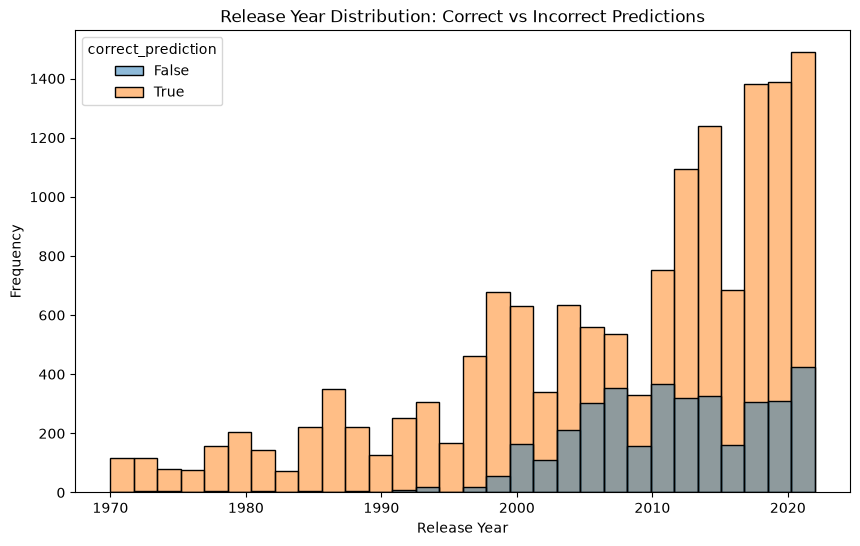

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=classification_df,
    x='year',
    hue='correct_prediction',
    bins=30,
    multiple='layer',
    alpha=0.5
)

plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.title("Release Year Distribution: Correct vs Incorrect Predictions")

plt.show()

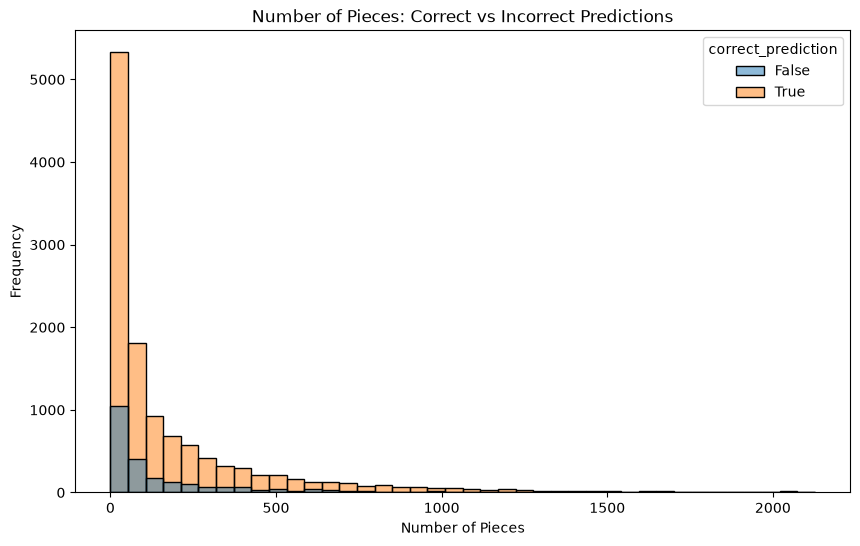

In [35]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=classification_df[
        classification_df['pieces'] <=
        classification_df['pieces'].quantile(0.99)
    ],
    x='pieces',
    hue='correct_prediction',
    bins=40,
    multiple='layer',
    alpha=0.5
)

plt.xlabel("Number of Pieces")
plt.ylabel("Frequency")
plt.title("Number of Pieces: Correct vs Incorrect Predictions")

plt.show()

In [36]:
classification_df['incorrect_prediction'] = (
    ~classification_df['correct_prediction']
)

themegroup_classification_errors = (
    classification_df
    .groupby('themeGroup')['incorrect_prediction']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'total_observations',
        'sum': 'incorrect_predictions',
        'mean': 'misclassification_rate'
    })
)

themegroup_classification_errors['misclassification_rate'] *= 100

themegroup_classification_errors = (
    themegroup_classification_errors
    .sort_values('misclassification_rate', ascending=False)
)

display(themegroup_classification_errors.round(2))

,total_observations,incorrect_predictions,misclassification_rate
themeGroup,,,
Model making,719,227,31.57
Technical,588,183,31.12
Racing,270,81,30.00
Pre-school,1537,437,28.43
Constraction,502,137,27.29
Miscellaneous,5891,1532,26.01
Licensed,2509,438,17.46
Historical,473,75,15.86
Action/Adventure,1397,173,12.38


In [37]:
category_classification_errors = (
    classification_df
    .groupby('category')['incorrect_prediction']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'total_observations',
        'sum': 'incorrect_predictions',
        'mean': 'misclassification_rate'
    })
)

category_classification_errors['misclassification_rate'] *= 100

category_classification_errors = (
    category_classification_errors
    .sort_values('misclassification_rate', ascending=False)
)

display(category_classification_errors.round(2))

,total_observations,incorrect_predictions,misclassification_rate
category,,,
Gear,2832,1225,43.26
Extended,501,134,26.75
Normal,12757,2213,17.35
Random,64,9,14.06
Collection,578,31,5.36
Book,631,18,2.85
Other,1094,13,1.19


### Interpretation

The classification errors are not distributed uniformly across the feature space.

The release-year distribution shows that incorrect predictions are more common in later years, particularly from the 2000s onward. However, the dataset also contains substantially more observations from recent years, so this pattern should not be interpreted as evidence that release year alone causes the increase in classification error.

The number-of-pieces distribution shows that most incorrect predictions occur among LEGO products with relatively low to moderate piece counts. However, this region also contains the majority of observations in the dataset, so the piece-count feature alone does not reveal as strong a systematic failure pattern as the categorical features.

Much clearer differences appear across categorical subpopulations. At the `themeGroup` level, the highest misclassification rates occur in `Model making` (30.88%), `Technical` (30.61%), `Racing` (29.63%), and `Pre-school` (28.43%). These groups therefore represent regions where the Logistic Regression classifier performs substantially worse than average.

At the `category` level, `Gear` is the most problematic group, with a misclassification rate of approximately 42.97%. This is considerably higher than the error rates observed for categories such as `Collection`, `Book`, and `Other`.

These results suggest that the classifier has systematic difficulty with certain product types rather than failing randomly across the dataset. One possible explanation is that the relationship between the selected features and price availability differs across product categories and theme groups. A linear decision boundary may not fully capture these subgroup-specific patterns.

Overall, the feature-based error analysis indicates that categorical subpopulations are a major source of classification difficulty, particularly `Gear`, `Model making`, `Technical`, `Racing`, and `Pre-school` products.


## 3.4 Threshold Sensitivity Analysis

The classification threshold determines how predicted probabilities are converted into class labels.

Rather than relying only on the default threshold of 0.5, model performance is evaluated across thresholds from 0.1 to 0.9.

For each threshold, Precision, Recall, F1-score, and Matthews Correlation Coefficient (MCC) are calculated in order to examine the trade-off between false positives and false negatives and identify stable or unstable operating regions.

In [38]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix
)

thresholds = np.arange(0.1, 1.0, 0.1)

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        y_class_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_class,
        threshold_pred
    )

    recall = recall_score(
        y_class,
        threshold_pred
    )

    f1 = f1_score(
        y_class,
        threshold_pred
    )

    mcc = matthews_corrcoef(
        y_class,
        threshold_pred
    )

    tn, fp, fn, tp = confusion_matrix(
        y_class,
        threshold_pred
    ).ravel()

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'MCC': mcc,
        'FP': fp,
        'FN': fn
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.round(3)
)

,Threshold,Precision,Recall,F1,MCC,FP,FN
0,0.1,0.657,0.995,0.791,0.291,5971,56
1,0.2,0.706,0.983,0.822,0.442,4694,191
2,0.3,0.740,0.961,0.836,0.499,3881,448
3,0.4,0.764,0.936,0.841,0.525,3317,734
4,0.5,0.864,0.810,0.836,0.591,1458,2185
5,0.6,0.899,0.775,0.832,0.614,1000,2582
6,0.7,0.946,0.668,0.783,0.591,440,3810
7,0.8,0.955,0.614,0.747,0.561,329,4432
8,0.9,0.974,0.509,0.669,0.505,154,5629


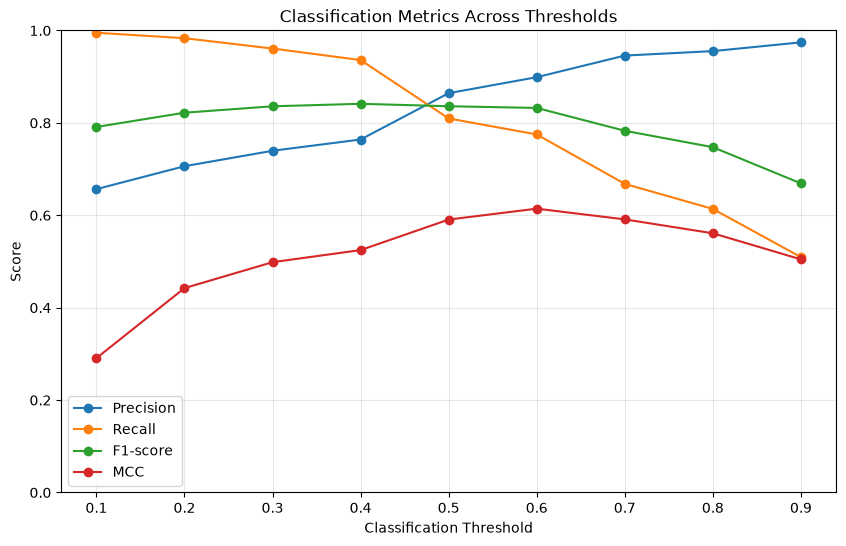

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1'],
    marker='o',
    label='F1-score'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['MCC'],
    marker='o',
    label='MCC'
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Classification Metrics Across Thresholds")

plt.xticks(thresholds)
plt.ylim(0, 1)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

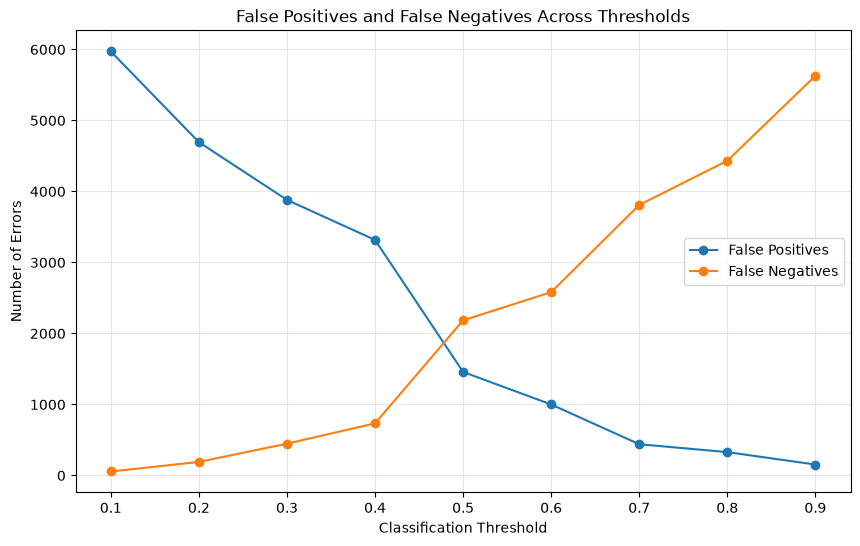

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['FP'],
    marker='o',
    label='False Positives'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['FN'],
    marker='o',
    label='False Negatives'
)

plt.xlabel("Classification Threshold")
plt.ylabel("Number of Errors")
plt.title("False Positives and False Negatives Across Thresholds")

plt.xticks(thresholds)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(
    y_class,
    y_class_prob
)

auc_score = roc_auc_score(
    y_class,
    y_class_prob
)

print("ROC-AUC:", round(auc_score, 3))

ROC-AUC: 0.891


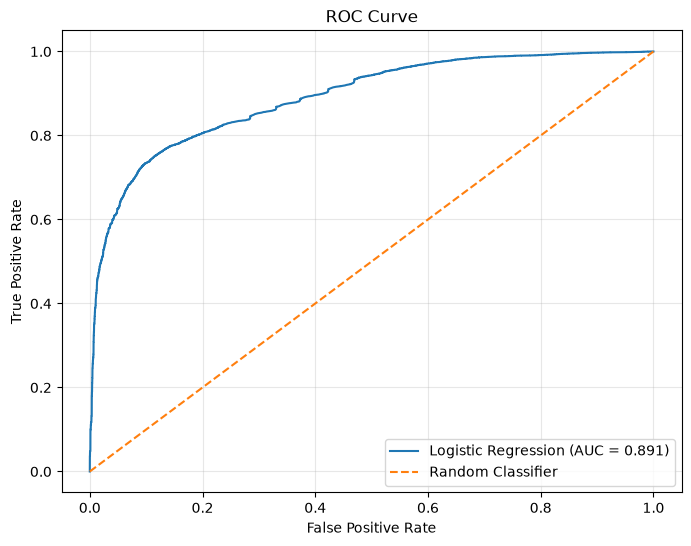

In [42]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {auc_score:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
from sklearn.metrics import fbeta_score

beta_values = np.arange(0.25, 3.25, 0.25)

fbeta_scores = []

for beta in beta_values:

    score = fbeta_score(
        y_class,
        y_class_pred,
        beta=beta
    )

    fbeta_scores.append(score)

fbeta_df = pd.DataFrame({
    'Beta': beta_values,
    'F_beta': fbeta_scores
})

display(fbeta_df.round(3))

,Beta,F_beta
0,0.25,0.861
1,0.50,0.853
2,0.75,0.844
3,1.00,0.836
4,1.25,0.830
5,1.50,0.826
6,1.75,0.822
7,2.00,0.820
8,2.25,0.818
9,2.50,0.817


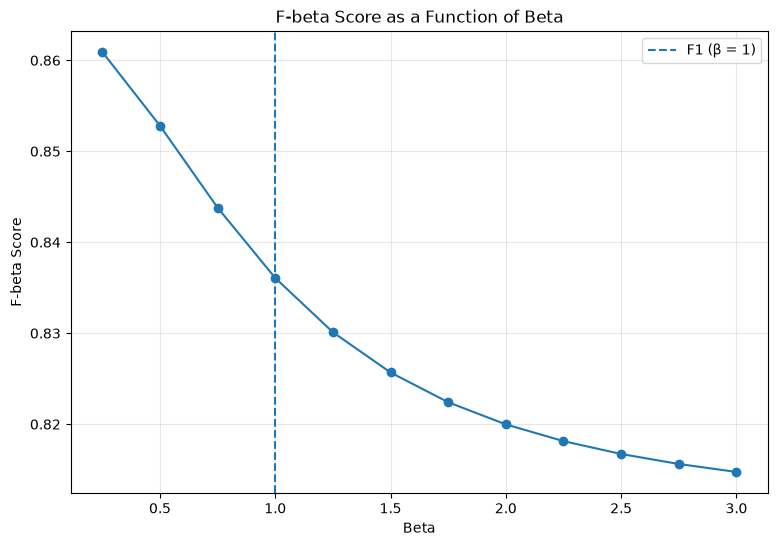

In [44]:
plt.figure(figsize=(9, 6))

plt.plot(
    fbeta_df['Beta'],
    fbeta_df['F_beta'],
    marker='o'
)

plt.axvline(
    x=1,
    linestyle='--',
    label='F1 (β = 1)'
)

plt.xlabel("Beta")
plt.ylabel("F-beta Score")
plt.title("F-beta Score as a Function of Beta")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The classification threshold has a clear effect on the trade-off between precision and recall.

At low thresholds, the classifier identifies almost all missing-price observations, resulting in very high recall. For example, at a threshold of 0.1, recall reaches 0.995, while precision is only 0.654. As the threshold increases, precision steadily improves while recall decreases.

The highest F1-score is obtained at a threshold of approximately 0.4, where (F1 = 0.842). This threshold provides a strong balance between precision and recall. The default threshold of 0.5 produces a very similar F1-score of 0.838.

The Matthews Correlation Coefficient reaches its maximum value of approximately 0.613 at a threshold of 0.6. This does not conflict with the F1 result, since MCC evaluates all four components of the confusion matrix, whereas F1 focuses on the balance between precision and recall for the positive class.

The region between approximately 0.3 and 0.6 appears relatively stable. Within this range, F1 remains high and MCC is also relatively strong. At thresholds above 0.6, recall decreases more sharply, increasing the risk of false negatives.

Because false negatives are considered more critical in this problem formulation, a slightly lower threshold such as 0.4 may be preferable when the main objective is to identify as many missing-price observations as possible.

The false-positive and false-negative counts show the same threshold trade-off more directly. As the classification threshold increases, the number of false positives decreases because the model becomes more conservative when predicting the missing-price class. At the same time, the number of false negatives increases because more actual missing-price observations fail to exceed the higher threshold.

This trade-off is particularly important in the current problem formulation because false negatives are considered more costly than false positives. Therefore, choosing a lower threshold can be justified when the priority is to minimize undetected missing-price observations, even if this results in additional false positives.

The ROC curve confirms that the classifier has good discriminative ability. The area under the ROC curve is approximately 0.891, indicating that the model can distinguish reasonably well between observations with missing and available retail prices across different classification thresholds.

The (F_\beta)-score also illustrates the effect of changing the relative importance of precision and recall. When (\beta < 1), greater weight is assigned to precision, while (\beta > 1) places greater emphasis on recall. The highest observed (F_\beta)-scores occur for smaller values of (\beta), which is consistent with the classifier's relatively strong precision.

At (\beta = 1), the metric becomes the F1-score, which is the harmonic mean of precision and recall:

[
F_1 = 2 \cdot \frac{\text{Precision}\cdot\text{Recall}}
{\text{Precision}+\text{Recall}}
]

The harmonic mean penalizes situations in which one of the two quantities is substantially lower than the other. Therefore, a high precision value cannot fully compensate for poor recall, and vice versa.

Overall, the threshold analysis demonstrates that there is no single universally optimal operating point. The preferred threshold depends on the relative importance of false positives and false negatives. For the current problem, thresholds around 0.4–0.5 provide a strong practical balance, while lower thresholds may be preferred when minimizing false negatives is the primary objective.


### Classification Model Comparison

To complement the detailed error analysis performed using Logistic Regression, additional classification models are evaluated using the same feature set and the same stratified 5-fold cross-validation procedure.

The models compared are:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

Using the same preprocessing pipeline and cross-validation strategy ensures a fair comparison between the models.

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Define classification models
logistic_classifier = logistic_model

decision_tree_classifier = Pipeline(steps=[
    ('preprocessor', classification_preprocessor),
    ('model', DecisionTreeClassifier(
        random_state=42
    ))
])

random_forest_classifier = Pipeline(steps=[
    ('preprocessor', classification_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

classification_models = {
    'Logistic Regression': logistic_classifier,
    'Decision Tree': decision_tree_classifier,
    'Random Forest': random_forest_classifier
}

classification_results = []

for model_name, model in classification_models.items():

    # Out-of-fold class predictions
    pred = cross_val_predict(
        model,
        X_class,
        y_class,
        cv=skf,
        method='predict',
        n_jobs=-1
    )

    # Out-of-fold probabilities
    prob = cross_val_predict(
        model,
        X_class,
        y_class,
        cv=skf,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    classification_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_class, pred),
        'Precision': precision_score(y_class, pred),
        'Recall': recall_score(y_class, pred),
        'F1': f1_score(y_class, pred),
        'ROC_AUC': roc_auc_score(y_class, prob)
    })

classification_results_df = pd.DataFrame(classification_results)

display(
    classification_results_df
    .sort_values('F1', ascending=False)
    .round(3)
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.915,0.960,0.901,0.930,0.971
1,Decision Tree,0.904,0.949,0.893,0.920,0.930
0,Logistic Regression,0.803,0.864,0.810,0.836,0.891


## 3.5 Discussion

The classification analysis compared three models using the same feature set and the same stratified 5-fold cross-validation procedure:

* Logistic Regression
* Decision Tree Classifier
* Random Forest Classifier

The Random Forest Classifier achieved the best overall performance across all evaluated metrics. It obtained an accuracy of 0.915, precision of 0.960, recall of 0.901, F1-score of 0.930, and ROC-AUC of 0.971.

The Decision Tree Classifier also performed strongly, with an accuracy of 0.904, precision of 0.949, recall of 0.893, F1-score of 0.920, and ROC-AUC of 0.930.

Logistic Regression produced weaker results than the two tree-based models, with an accuracy of 0.805, precision of 0.866, recall of 0.810, F1-score of 0.838, and ROC-AUC of 0.891. Nevertheless, it served as an important and interpretable baseline for the detailed classification error analysis.

The results indicate that the relationship between the selected LEGO features and price availability is not fully represented by a simple linear decision boundary. Logistic Regression assumes that the log-odds of the target can be expressed as a linear combination of the transformed input features. The stronger performance of the Decision Tree and Random Forest suggests that non-linear relationships and interactions between features play an important role in determining whether retail-price information is available.

The detailed error analysis of Logistic Regression showed several important failure modes. The confusion matrix contained 1,433 false positives and 2,175 false negatives. In the current problem formulation, false negatives are considered more critical because they represent observations with missing retail-price information that the classifier fails to detect.

The probability-based analysis also identified 204 high-confidence errors, representing approximately 5.65% of all incorrect Logistic Regression predictions. These cases are particularly important because the model assigns high confidence to predictions that are nevertheless incorrect, suggesting that some observations contain feature combinations that are poorly represented by the model.

The feature-based analysis showed that classification errors are concentrated in specific subpopulations rather than being randomly distributed. At the `themeGroup` level, `Model making`, `Technical`, `Racing`, and `Pre-school` showed some of the highest misclassification rates. At the `category` level, `Gear` was especially difficult, with a misclassification rate of approximately 42.97%.

These subgroup-specific failure patterns help explain why the tree-based classifiers outperform Logistic Regression. Decision Trees can model non-linear relationships and feature interactions directly, while Random Forest reduces the instability and variance associated with a single tree by averaging predictions across many trees.

There is also a trade-off between interpretability and predictive performance. Logistic Regression is the easiest model to interpret and provides a clear baseline. A Decision Tree is also relatively interpretable through its decision structure, but it may be more sensitive to noise and overfitting. Random Forest provides the strongest predictive performance and robustness, but its ensemble structure makes individual predictions more difficult to interpret.

The threshold sensitivity analysis showed that Logistic Regression performance can also be adjusted according to the relative importance of false positives and false negatives. The highest F1-score was obtained around a threshold of 0.4, while MCC reached its maximum around 0.6. Because false negatives are considered more important in this problem, a slightly lower threshold may be preferred when the objective is to identify as many missing-price observations as possible.

Overall, Random Forest is the preferred classification model for future analysis because it achieved the highest accuracy, F1-score, recall, precision, and ROC-AUC while maintaining strong generalization performance. However, Logistic Regression remains valuable as an interpretable baseline and as a useful model for understanding systematic error patterns.

### Recommendations for Improvement

Several improvements could be considered in future work:

1. Perform hyperparameter tuning for the Decision Tree and Random Forest models using cross-validation.

2. Evaluate additional ensemble methods such as Gradient Boosting.

3. Investigate additional feature engineering, particularly interactions between product category, theme group, release period, and numerical characteristics.

4. Examine high-confidence errors individually to identify possible missing variables, unusual products, or systematic data-quality patterns.

5. Select the classification threshold according to the practical cost of false positives and false negatives rather than automatically using the default threshold of 0.5.

6. Investigate subgroup-specific performance in greater detail to determine whether certain product categories require different modeling strategies.

Overall, the classification stage demonstrates that model choice has a substantial effect on predictive performance. More flexible tree-based models capture important structure that Logistic Regression does not fully represent, while the detailed error analysis reveals where even a reasonably accurate classifier can still fail systematically.


# 4. Final Reflection

The analysis showed that model failures are concentrated in specific regions of the LEGO dataset rather than being randomly distributed.

For the regression task, the largest errors occurred mainly for specialized and unusual products. Educational and Technical products, very large collector sets, and observations with missing feature information were especially difficult to predict accurately. The residual analysis also showed heteroscedasticity and extremely heavy-tailed errors, indicating that the Linear Regression model does not fully capture the pricing behavior of all LEGO products.

For the classification task, the model performed worst in specific categorical subgroups. In particular, the `Gear` category showed a very high misclassification rate, while theme groups such as `Model making`, `Technical`, `Racing`, and `Pre-school` were also substantially more difficult to classify than other groups.

The observed failures appear to result from a combination of data, model, and problem-formulation factors. Missing feature values reduce the amount of information available to the models, while rare and specialized LEGO products occupy regions of the feature space that are less well represented in the dataset. At the same time, simple linear models such as Linear Regression and Logistic Regression may not adequately capture non-linear relationships and complex feature interactions.

Several improvements could be considered. More flexible models such as Random Forests or Gradient Boosting could be used to capture non-linear relationships and interactions. Hyperparameter tuning could improve generalization, and additional feature engineering could help represent product type, release period, and interactions between categorical variables more effectively. For classification, the decision threshold should also be selected according to the relative importance of false positives and false negatives rather than relying automatically on the default value of 0.5.

The most important insight from the analysis is that predictive performance alone does not provide a complete picture of model quality. Two models with similar overall metrics may behave very differently across subgroups, thresholds, or unusual observations. Error analysis therefore provides essential information about where a model can be trusted, where it is likely to fail, and what types of improvements are most likely to increase robustness and reliability.
